<a href="https://colab.research.google.com/github/Sairam307/Customer_Churn_Analysis/blob/main/Customer_Churn_UPGRADED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Customer Churn Analysis — Upgraded Version
**Telecom Company 'Neo' — Predict & Prevent Customer Churn**

---
### 📌 Business Problem
Neo Telecom is losing customers to competitors. Our goal is to:
1. **Understand** which customer segments are most likely to churn
2. **Build a model** that predicts whether a customer will churn (Yes/No)
3. **Give business recommendations** so the company can take action before losing the customer

---
### 📋 Dataset Info
- **7,043 customers** | **21 columns**
- Target variable: `Churn` (Yes = customer left, No = customer stayed)
- Mix of demographic, service, and billing information

---
## ✅ STEP 1 — Import Libraries & Load Data

In [ ]:
# ── Core Libraries ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocessing ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Models ─────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Evaluation Metrics ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

# ── Model Saving ───────────────────────────────────────────────────────────────
import joblib

import warnings
warnings.filterwarnings('ignore')

# ── Plot Style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()  # Upload daily_prices.csv
df = pd.read_csv('customer churn.csv')

print(f'Shape: {df.shape}')   # rows × columns
df.head(3)

Saving customer churn.csv to customer churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
## 🧹 STEP 2 — Data Cleaning
Before any analysis, we fix data quality issues. Dirty data = wrong insights.

In [ ]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('=== Data Types & Null Count ===')
df.info()

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())

=== Data Types & Null Count ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

In [ ]:
# ── FIX 1: TotalCharges is stored as 'object' (string) — should be float ──────
# This happens because some rows have a space ' ' instead of a number

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many rows became NaN after conversion
print(f'TotalCharges null count after conversion: {df["TotalCharges"].isnull().sum()}')

# Fill those nulls with the median (safe strategy — not affected by outliers)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print('✅ TotalCharges fixed — now numeric')

TotalCharges null count after conversion: 11
✅ TotalCharges fixed — now numeric


In [ ]:
# ── FIX 2: Drop customerID — it is just an identifier, not a feature ──────────
# Using customerID as a model feature would be wrong — it has no predictive power

df.drop('customerID', axis=1, inplace=True)

print(f'Columns after dropping customerID: {df.shape[1]}')
print(df.columns.tolist())

Columns after dropping customerID: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


---
## 📊 STEP 3 — ADVANCED EDA (Exploratory Data Analysis)

> **Why EDA matters to employers:** EDA shows you can think like a business analyst — not just run code. Every chart must answer a business question.

### 3.1 — Target Variable: Class Imbalance Check
**Business Question:** How many customers actually churned? Is the data balanced?

=== Churn Distribution ===
       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


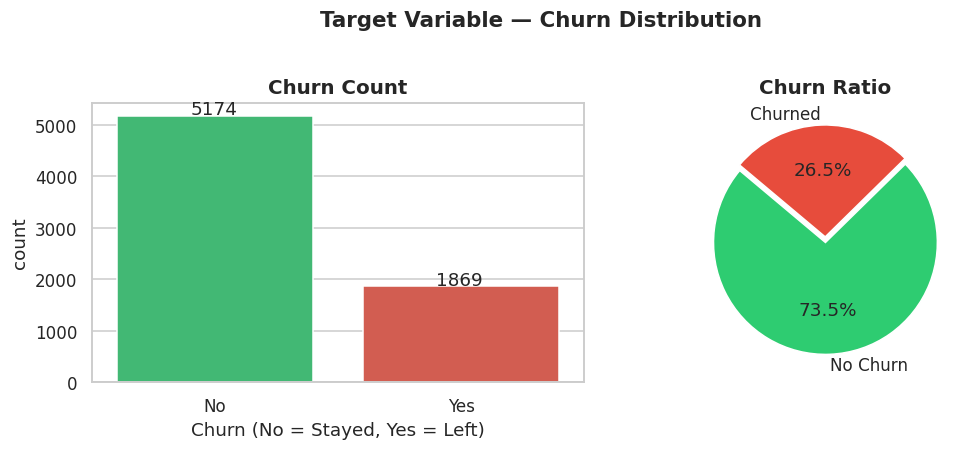


📌 BUSINESS INSIGHT:
  → Only 26.5% of customers churned (1869 out of 7043)
  → This is an IMBALANCED dataset — if we do nothing, the model will just predict "No" for everyone
  → And still get 73.5% accuracy! That is misleading — we must handle this.


In [ ]:
# ── Churn Distribution ────────────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn (No = Stayed, Yes = Left)')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+30))

# Pie chart
axes[1].pie(churn_counts, labels=['No Churn','Churned'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=140, explode=(0, 0.05))
axes[1].set_title('Churn Ratio', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print('📌 BUSINESS INSIGHT:')
print(f'  → Only {churn_pct["Yes"]:.1f}% of customers churned ({churn_counts["Yes"]} out of {len(df)})')
print(f'  → This is an IMBALANCED dataset — if we do nothing, the model will just predict "No" for everyone')
print(f'  → And still get {churn_pct["No"]:.1f}% accuracy! That is misleading — we must handle this.')

### 3.2 — Feature Distribution by Churn (Categorical Features)
**Business Question:** Which customer types are more likely to churn?

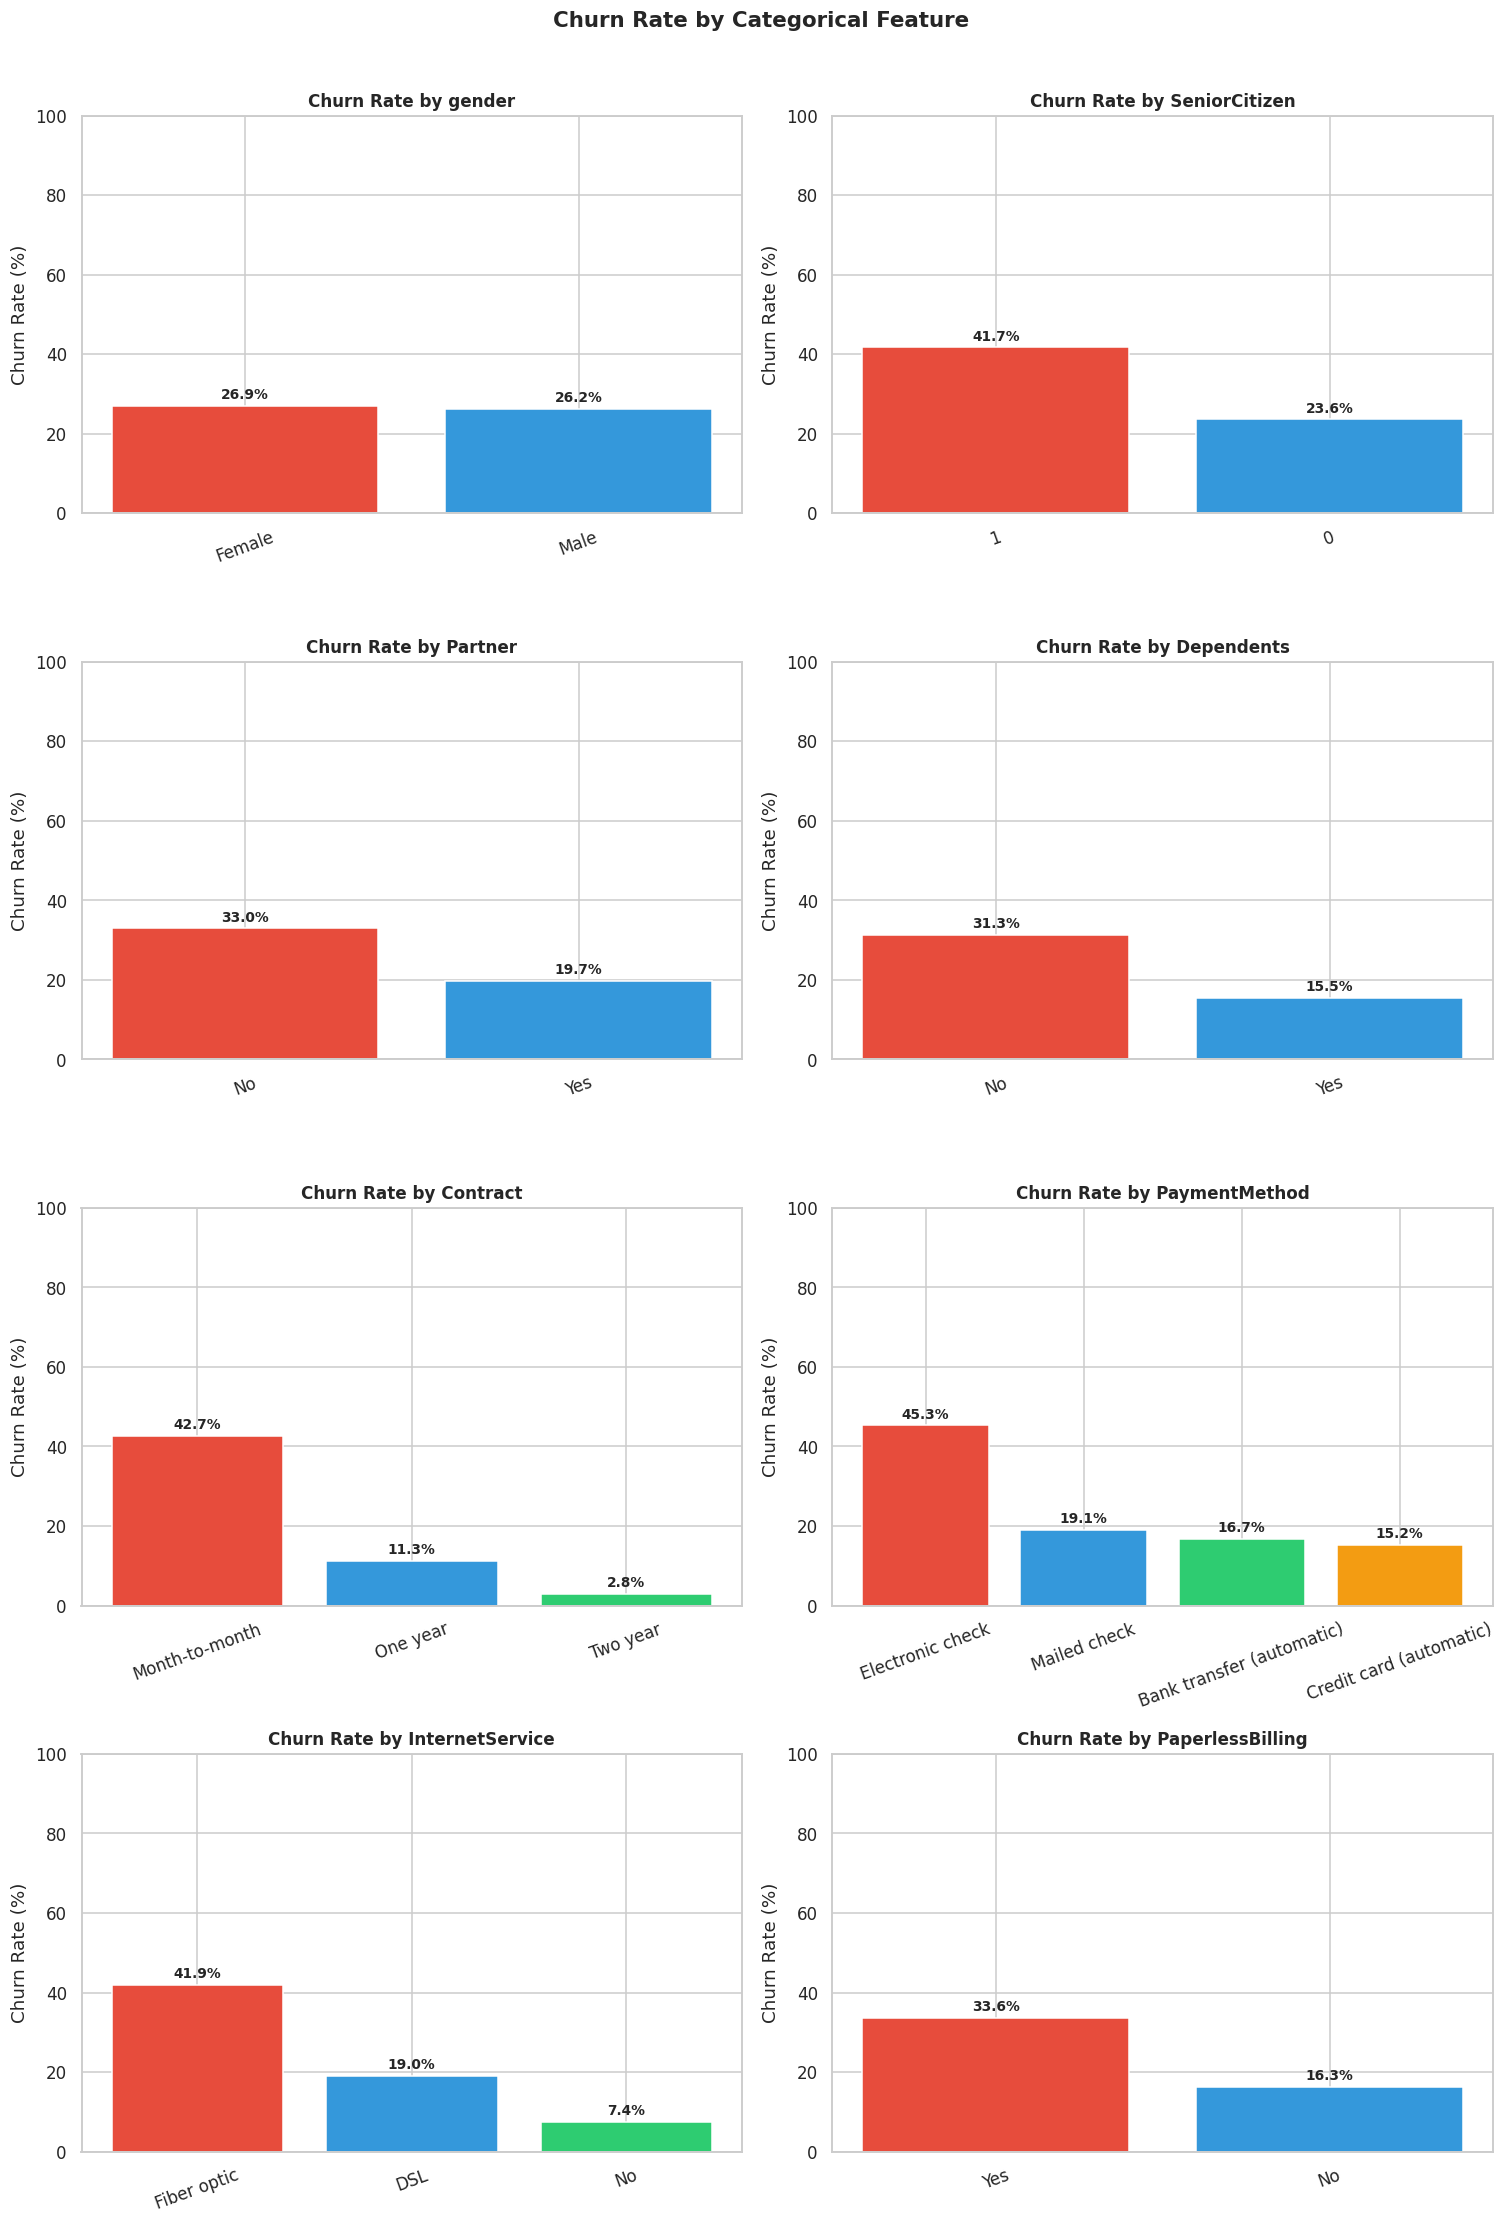

📌 BUSINESS INSIGHTS from Categorical Features:
  → Contract type: Month-to-month customers churn MUCH more than 1-year or 2-year contract customers
    ACTION: Push customers to sign longer contracts with loyalty discounts
  → Senior citizens churn at a higher rate — they may need more support/simpler plans
    ACTION: Create a dedicated senior citizen support plan
  → Customers without Partner or Dependents churn more — they have less "lock-in"
    ACTION: Offer family bundle deals to increase stickiness
  → Electronic check users churn most — friction in payment may cause frustration
    ACTION: Offer incentives to switch to auto-pay (bank transfer / credit card)


In [ ]:
'Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Calculate churn rate within each category
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(churn_rate[col].astype(str), churn_rate['ChurnRate'],
                       color=['#e74c3c','#3498db','#2ecc71','#f39c12'][:len(churn_rate)])
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=20)
    # Add value labels on bars
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     f'{bar.get_height():.1f}%',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('📌 BUSINESS INSIGHTS from Categorical Features:')
print('  → Contract type: Month-to-month customers churn MUCH more than 1-year or 2-year contract customers')
print('    ACTION: Push customers to sign longer contracts with loyalty discounts')
print('  → Senior citizens churn at a higher rate — they may need more support/simpler plans')
print('    ACTION: Create a dedicated senior citizen support plan')
print('  → Customers without Partner or Dependents churn more — they have less "lock-in"')
print('    ACTION: Offer family bundle deals to increase stickiness')
print('  → Electronic check users churn most — friction in payment may cause frustration')
print('    ACTION: Offer incentives to switch to auto-pay (bank transfer / credit card)')

### 3.3 — Numeric Feature Distribution by Churn
**Business Question:** Do churned customers have different tenure or charges?

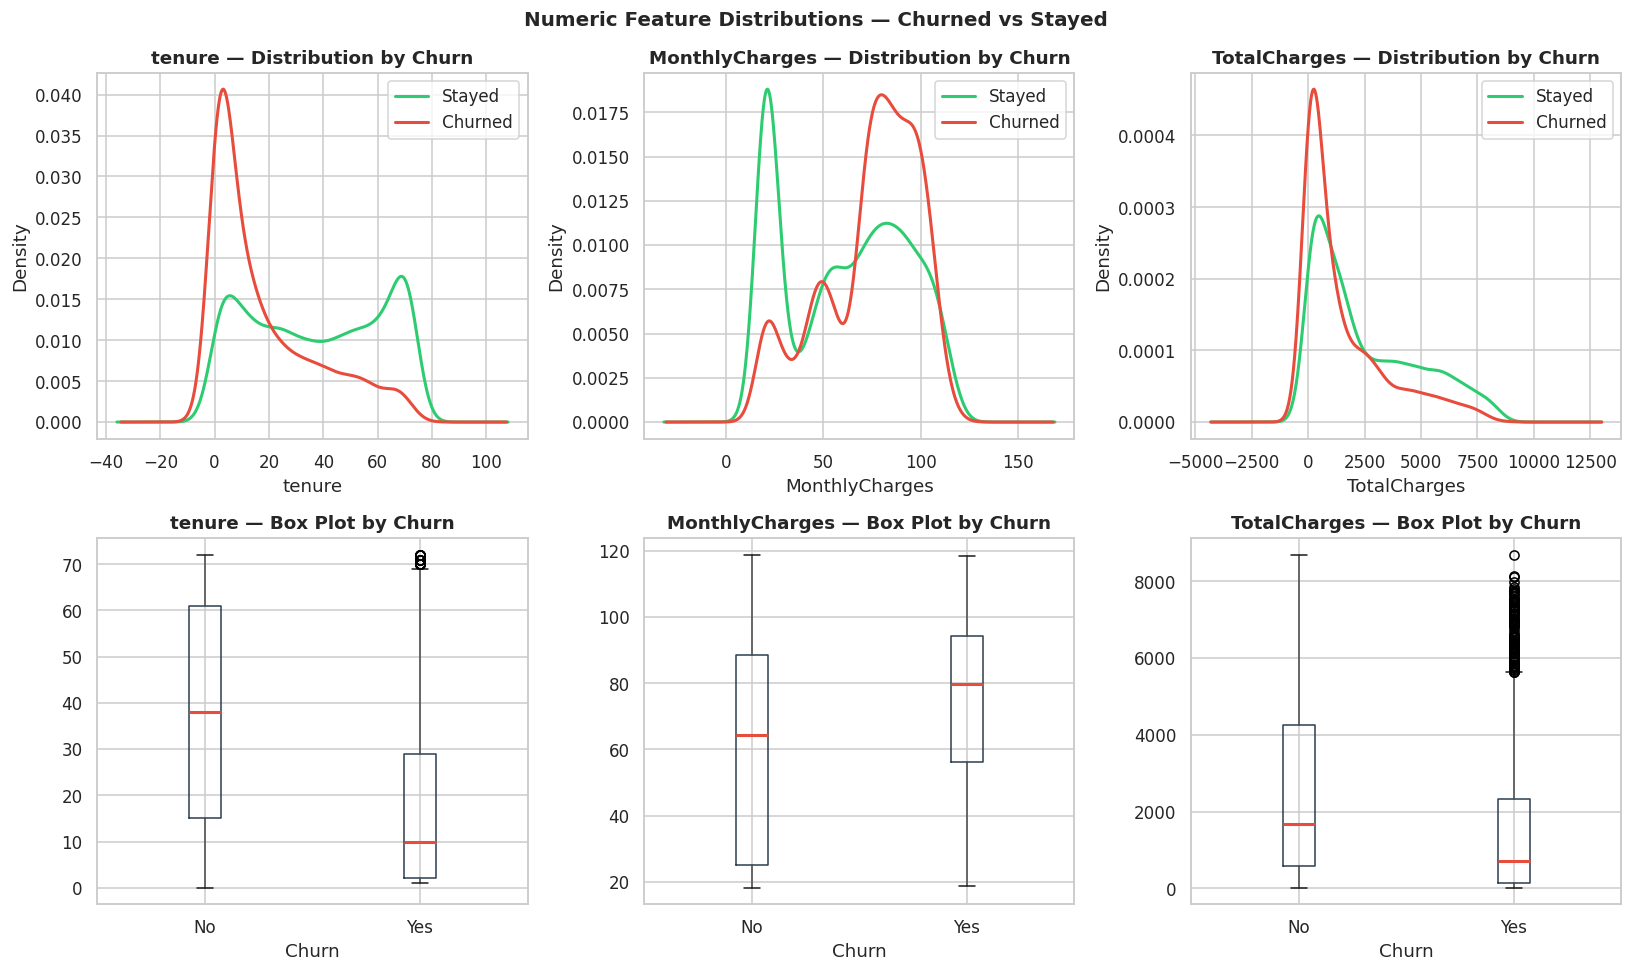

=== Median Values: Churned vs Stayed ===
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0            64.4        1679.5
Yes      10.0            79.6         703.6

📌 BUSINESS INSIGHTS from Numeric Features:
  → TENURE: Churned customers have MUCH shorter tenure (median ~10 months)
    This means the first 12 months are the most critical — highest churn risk window
    ACTION: Create a 12-month loyalty program for new customers
  → MONTHLY CHARGES: Churned customers pay MORE per month
    High-paying customers feel the value gap more acutely and leave
    ACTION: Offer loyalty discounts to high-paying customers after 3 months
  → TOTAL CHARGES: Churned customers have lower total charges (because they leave early)


In [ ]:
# ── Numeric Features: KDE + Box Plot ─────────────────────────────────────────
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(num_features):
    # Row 1: KDE distribution — shows shape of distribution for churned vs not churned
    for churn_val, color, label in [('No','#2ecc71','Stayed'), ('Yes','#e74c3c','Churned')]:
        subset = df[df['Churn'] == churn_val][col]
        subset.plot.kde(ax=axes[0, i], color=color, label=label, linewidth=2)
    axes[0, i].set_title(f'{col} — Distribution by Churn', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()
    axes[0, i].set_ylabel('Density')

    # Row 2: Box plot — shows median, spread, and outliers
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    axes[1, i].set_title(f'{col} — Box Plot by Churn', fontweight='bold')
    axes[1, i].set_xlabel('Churn')

plt.suptitle('Numeric Feature Distributions — Churned vs Stayed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print actual median values for business context
print('=== Median Values: Churned vs Stayed ===')
print(df.groupby('Churn')[num_features].median().round(1))
print()
print('📌 BUSINESS INSIGHTS from Numeric Features:')
print('  → TENURE: Churned customers have MUCH shorter tenure (median ~10 months)')
print('    This means the first 12 months are the most critical — highest churn risk window')
print('    ACTION: Create a 12-month loyalty program for new customers')
print('  → MONTHLY CHARGES: Churned customers pay MORE per month')
print('    High-paying customers feel the value gap more acutely and leave')
print('    ACTION: Offer loyalty discounts to high-paying customers after 3 months')
print('  → TOTAL CHARGES: Churned customers have lower total charges (because they leave early)')

### 3.4 — Correlation Heatmap
**Business Question:** Which features are most related to each other? Are there redundant features?

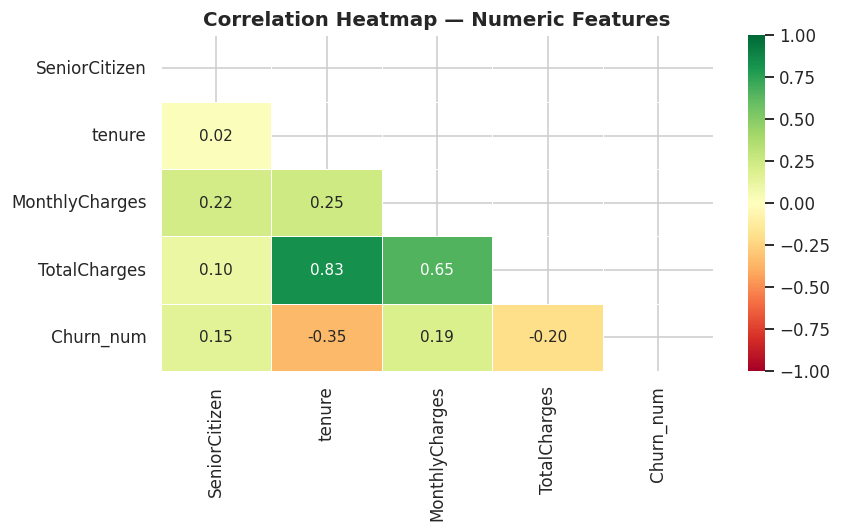

📌 BUSINESS INSIGHTS from Correlation Heatmap:
  → tenure vs TotalCharges: STRONG positive correlation (~0.83)
    Longer customers = more total charges (expected — they pay more over time)
    IMPLICATION: TotalCharges is partly redundant if tenure is in the model
  → Churn vs tenure: NEGATIVE correlation — longer tenure = LESS likely to churn
    IMPLICATION: Tenure is our strongest predictor — keep it as a top feature
  → Churn vs MonthlyCharges: POSITIVE — higher charges = more likely to churn
    IMPLICATION: Price sensitivity is real — review pricing for high-charge customers


In [ ]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
# We can only compute correlation on numeric columns
# First, encode Churn as 0/1 temporarily so it appears in the heatmap

df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

numeric_cols = df_corr.select_dtypes(include=['number']).columns
corr_matrix  = df_corr[numeric_cols].corr()

plt.figure(figsize=(8, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 BUSINESS INSIGHTS from Correlation Heatmap:')
print('  → tenure vs TotalCharges: STRONG positive correlation (~0.83)')
print('    Longer customers = more total charges (expected — they pay more over time)')
print('    IMPLICATION: TotalCharges is partly redundant if tenure is in the model')
print('  → Churn vs tenure: NEGATIVE correlation — longer tenure = LESS likely to churn')
print('    IMPLICATION: Tenure is our strongest predictor — keep it as a top feature')
print('  → Churn vs MonthlyCharges: POSITIVE — higher charges = more likely to churn')
print('    IMPLICATION: Price sensitivity is real — review pricing for high-charge customers')

---
## 🔧 STEP 4 — Feature Engineering & Preprocessing

> **Why this matters:** Machine learning models only understand numbers. We must convert all text (Yes/No, Male/Female, contract types) into numeric format. Skipping this means the model ignores all those columns.

### 4.1 — Encode Categorical Features

In [ ]:
# ── Step 4.1: Separate target variable BEFORE encoding ────────────────────────
# Always separate target first — we don't want to accidentally transform it

df_model = df.copy()

# Encode target: Yes → 1, No → 0
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

print('Churn encoding check:')
print(df_model['Churn'].value_counts())

Churn encoding check:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# ── Step 4.2: Encode binary categorical columns using LabelEncoder ─────────────
# Binary = only 2 values (Yes/No, Male/Female)
# LabelEncoder converts: 'Female'→0, 'Male'→1  /  'No'→0, 'Yes'→1

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'  {col}: {df[col].unique()} → {df_model[col].unique()}')

  gender: ['Female' 'Male'] → [0 1]
  Partner: ['Yes' 'No'] → [1 0]
  Dependents: ['No' 'Yes'] → [0 1]
  PhoneService: ['No' 'Yes'] → [0 1]
  PaperlessBilling: ['Yes' 'No'] → [1 0]
  MultipleLines: ['No phone service' 'No' 'Yes'] → [1 0 2]


In [ ]:
# ── Step 4.3: One-Hot Encode multi-category columns ───────────────────────────
# Multi-category = more than 2 values (e.g. Contract has 3 types)
# Why one-hot? Because Label Encoding on multi-category implies a wrong ordering
# e.g. Contract: 'Month-to-month'=0, 'One year'=1, 'Two year'=2
#      This wrongly implies 'Two year' is '2x better' than 'Month-to-month'
#      One-hot avoids this by creating separate 0/1 columns for each category

multi_cat_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV',
                  'StreamingMovies', 'Contract', 'PaymentMethod']

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print(f'Shape after encoding: {df_model.shape}')
print(f'New columns added: {df_model.shape[1] - 11} columns from encoding')
df_model.head(2)

Shape after encoding: (7043, 30)
New columns added: 19 columns from encoding


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True


### 4.2 — Train-Test Split & Feature Scaling

In [ ]:
# ── Step 4.4: Define Features (X) and Target (y) ─────────────────────────────
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print(f'Churn rate in data: {y.mean()*100:.1f}%')

Feature matrix X shape: (7043, 29)
Target vector y shape:  (7043,)
Churn rate in data: 26.5%


In [ ]:
# ── Step 4.5: Train-Test Split (80:20) ────────────────────────────────────────
# stratify=y is critical for imbalanced data
# It ensures both train and test have the same churn ratio (26.5%)
# Without stratify: test set could accidentally have 10% or 40% churn — misleading results

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test set:     {X_test.shape[0]} rows  | Churn rate: {y_test.mean()*100:.1f}%')
print('✅ Churn rates are balanced in both sets — stratify worked')

Training set: 5634 rows | Churn rate: 26.5%
Test set:     1409 rows  | Churn rate: 26.5%
✅ Churn rates are balanced in both sets — stratify worked


In [ ]:
# ── Step 4.6: Feature Scaling (StandardScaler) ────────────────────────────────
# WHY scale? Logistic Regression uses gradient descent
# If one column is 0-72 (tenure) and another is 18-118 (MonthlyCharges),
# the larger scale dominates — the model learns badly
# StandardScaler converts everything to mean=0, std=1 — fair playing field

# IMPORTANT RULE: Fit scaler ONLY on train set, then transform both
# If you fit on all data, you 'leak' test information into training — that is cheating

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc  = scaler.transform(X_test)        # ONLY transform on test (no fit)

print('✅ Scaling done')
print(f'Before scaling — tenure mean: {X_train["tenure"].mean():.1f}, std: {X_train["tenure"].std():.1f}')
print(f'After scaling  — tenure mean: {X_train_sc[:, X_train.columns.get_loc("tenure")].mean():.3f}')

✅ Scaling done
Before scaling — tenure mean: 32.5, std: 24.6
After scaling  — tenure mean: -0.000


---
## 🤖 STEP 5 — Model Building: Compare 4 Models

> **Why compare multiple models?** No single model is always best. We try several and pick the one with the best performance on this specific data. This shows employers you think like a Data Scientist — not just someone who runs one model and stops.

> **Why `class_weight='balanced'`?** Our data has 73% No and 27% Yes. Without this, the model ignores the minority class (churners). Balanced weight forces the model to pay equal attention to both classes.

In [ ]:
# ── Define 4 models to compare ────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=5, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, max_depth=8, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
    ),
}

# ── Train all models and collect results ──────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)            # train
    y_pred  = model.predict(X_test_sc)         # predict class labels
    y_prob  = model.predict_proba(X_test_sc)[:, 1]  # predict probabilities

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob) * 100, 2),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'model':     model,
    }

# ── Print comparison table ────────────────────────────────────────────────────
print('=' * 50)
print(f'{"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print('=' * 50)
for name, r in results.items():
    print(f'{name:<25} {r["Accuracy"]:>9}%  {r["ROC-AUC"]:>9}%')
print('=' * 50)
print()
print('📌 WHY ROC-AUC IS THE BETTER METRIC HERE:')
print('  Accuracy is misleading for imbalanced data.')
print('  A model predicting "No" for everyone = 73% accuracy — that is useless!')
print('  ROC-AUC measures how well the model RANKS churners above non-churners.')
print('  AUC = 0.5 → random guessing | AUC = 1.0 → perfect model')

Model                       Accuracy    ROC-AUC
Logistic Regression           73.95%      84.11%
Decision Tree                 73.46%      83.08%
Random Forest                 76.01%      84.55%
Gradient Boosting             80.06%      84.17%

📌 WHY ROC-AUC IS THE BETTER METRIC HERE:
  Accuracy is misleading for imbalanced data.
  A model predicting "No" for everyone = 73% accuracy — that is useless!
  ROC-AUC measures how well the model RANKS churners above non-churners.
  AUC = 0.5 → random guessing | AUC = 1.0 → perfect model


### 5.1 — K-Fold Cross Validation
**Why?** A single train-test split can be lucky or unlucky. Cross-validation gives a more reliable estimate of true model performance.

In [ ]:
# ── 5-Fold Stratified Cross Validation ───────────────────────────────────────
# StratifiedKFold ensures each fold maintains the 73/27 churn ratio
# We use ROC-AUC as the scoring metric (more reliable for imbalanced data)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== 5-Fold Cross Validation (ROC-AUC) ===')
print(f'{"Model":<25} {"Mean AUC":>10} {"Std Dev":>10}')
print('-' * 50)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    print(f'{name:<25} {cv_scores.mean()*100:>9.2f}%  ±{cv_scores.std()*100:>7.2f}%')

print()
print('📌 HOW TO READ THIS:')
print('  → Mean AUC: average performance across 5 folds (higher is better)')
print('  → Std Dev: consistency of the model (lower is better)')
print('  → A model with 82% ± 1% is MORE trustworthy than 84% ± 6%')
print('  → Low std dev = model is stable, not dependent on which data it sees')

=== 5-Fold Cross Validation (ROC-AUC) ===
Model                       Mean AUC    Std Dev
--------------------------------------------------
Logistic Regression           84.60%  ±   1.24%
Decision Tree                 82.41%  ±   0.83%
Random Forest                 84.60%  ±   1.09%
Gradient Boosting             84.46%  ±   1.10%

📌 HOW TO READ THIS:
  → Mean AUC: average performance across 5 folds (higher is better)
  → Std Dev: consistency of the model (lower is better)
  → A model with 82% ± 1% is MORE trustworthy than 84% ± 6%
  → Low std dev = model is stable, not dependent on which data it sees


---
## 📈 STEP 6 — Model Evaluation

### 6.1 — ROC Curves (All Models)

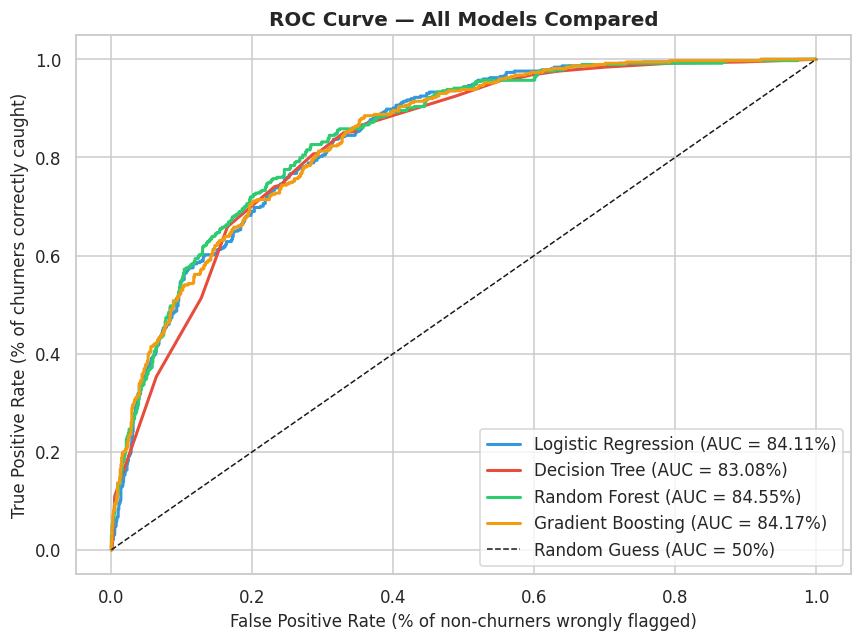

📌 HOW TO EXPLAIN ROC-AUC IN AN INTERVIEW:
  "ROC-AUC tells us how well the model distinguishes between churners and non-churners.
   An AUC of 0.84 means there is an 84% chance the model will rank a random churner
   higher than a random non-churner. This is far better than the 50% chance of random guessing."


In [ ]:
# ── ROC Curve for all 4 models ────────────────────────────────────────────────
# ROC Curve plots: True Positive Rate vs False Positive Rate
# TPR (Recall) = what % of actual churners did we catch?
# FPR          = what % of non-churners did we wrongly flag?
# The closer the curve is to the top-left corner, the better

plt.figure(figsize=(8, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['ROC-AUC']}%)", color=color, linewidth=2)

# Diagonal = random guessing baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess (AUC = 50%)')

plt.xlabel('False Positive Rate (% of non-churners wrongly flagged)', fontsize=11)
plt.ylabel('True Positive Rate (% of churners correctly caught)', fontsize=11)
plt.title('ROC Curve — All Models Compared', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('📌 HOW TO EXPLAIN ROC-AUC IN AN INTERVIEW:')
print('  "ROC-AUC tells us how well the model distinguishes between churners and non-churners.')
print('   An AUC of 0.84 means there is an 84% chance the model will rank a random churner')
print('   higher than a random non-churner. This is far better than the 50% chance of random guessing."')

### 6.2 — Confusion Matrices

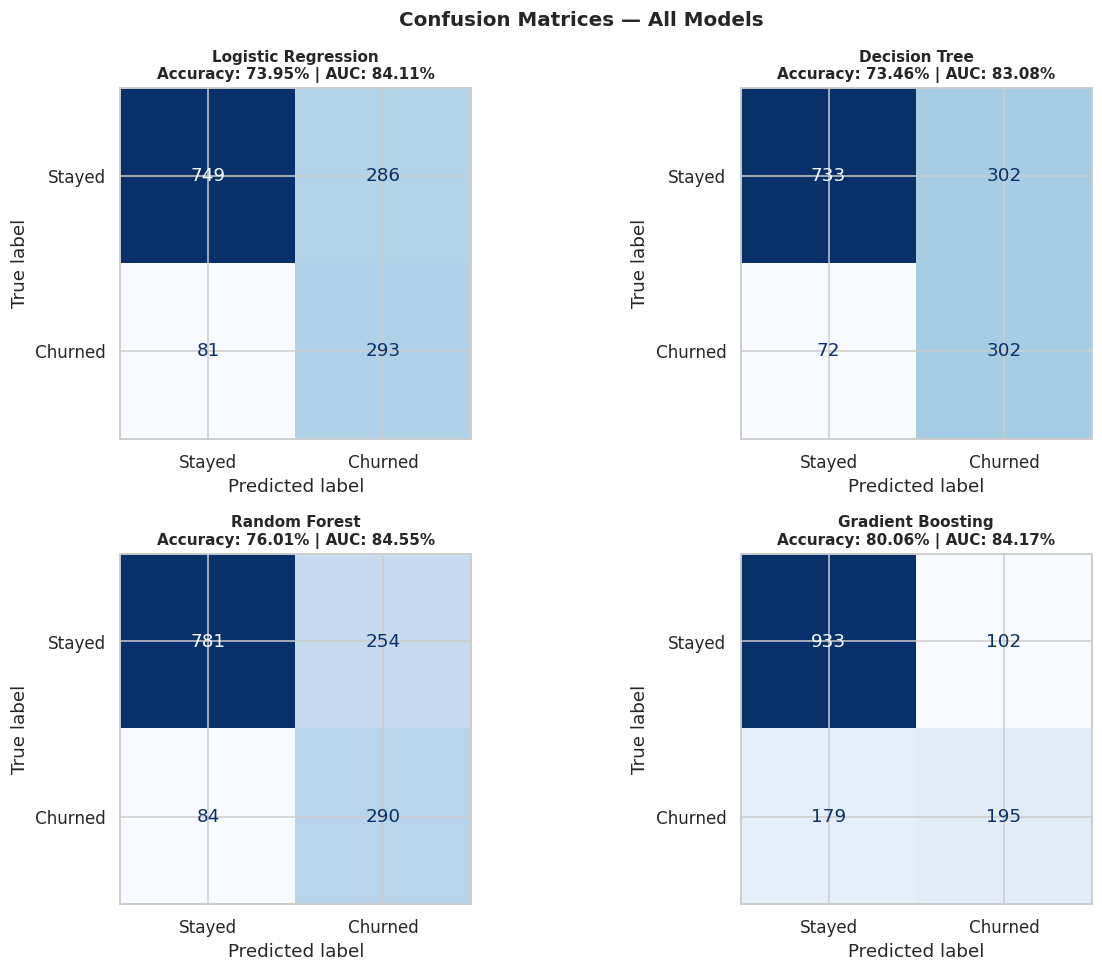

📌 HOW TO READ THE CONFUSION MATRIX:
  Top-left  (True Negative):  Customers who stayed — model correctly predicted "Stayed"
  Top-right (False Positive): Customers who stayed — model wrongly predicted "Churned"
  Bot-left  (False Negative): Customers who CHURNED — model missed them (predicted "Stayed")
  Bot-right (True Positive):  Customers who CHURNED — model correctly predicted "Churned"

  → False Negatives are MOST COSTLY for the business
    Missing a churner = losing a customer with zero chance to retain them
    So we want HIGH RECALL on the Churned class


In [ ]:
# ── Confusion Matrices for all 4 models ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed','Churned'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAccuracy: {r["Accuracy"]}% | AUC: {r["ROC-AUC"]}%',
                      fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 HOW TO READ THE CONFUSION MATRIX:')
print('  Top-left  (True Negative):  Customers who stayed — model correctly predicted "Stayed"')
print('  Top-right (False Positive): Customers who stayed — model wrongly predicted "Churned"')
print('  Bot-left  (False Negative): Customers who CHURNED — model missed them (predicted "Stayed")')
print('  Bot-right (True Positive):  Customers who CHURNED — model correctly predicted "Churned"')
print()
print('  → False Negatives are MOST COSTLY for the business')
print('    Missing a churner = losing a customer with zero chance to retain them')
print('    So we want HIGH RECALL on the Churned class')

### 6.3 — Classification Report (Best Model)

In [ ]:
# ── Select the best model based on ROC-AUC ───────────────────────────────────
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best      = results[best_name]

print(f'🏆 Best Model: {best_name}')
print(f'   ROC-AUC: {best["ROC-AUC"]}%  |  Accuracy: {best["Accuracy"]}%')
print()
print('=== Detailed Classification Report ===')
print(classification_report(y_test, best['y_pred'], target_names=['Stayed','Churned']))

print('📌 WHICH METRIC MATTERS MOST — AND WHY:')
print('  For churn prediction, RECALL on the "Churned" class is most important')
print('  Recall = what % of actual churners did we identify?')
print('  Missing a churner (False Negative) = no retention action taken = lost customer')
print('  Wrongly flagging a non-churner (False Positive) = we offer them a discount = small cost')
print('  Losing a customer is MORE expensive than giving an unnecessary discount')
print('  Therefore: Maximize RECALL, accept some drop in Precision')

🏆 Best Model: Random Forest
   ROC-AUC: 84.55%  |  Accuracy: 76.01%

=== Detailed Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.90      0.75      0.82      1035
     Churned       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

📌 WHICH METRIC MATTERS MOST — AND WHY:
  For churn prediction, RECALL on the "Churned" class is most important
  Recall = what % of actual churners did we identify?
  Missing a churner (False Negative) = no retention action taken = lost customer
  Wrongly flagging a non-churner (False Positive) = we offer them a discount = small cost
  Losing a customer is MORE expensive than giving an unnecessary discount
  Therefore: Maximize RECALL, accept some drop in Precision


---
## 💡 STEP 7 — Feature Importance
**Business Question:** Which factors most predict whether a customer will churn?

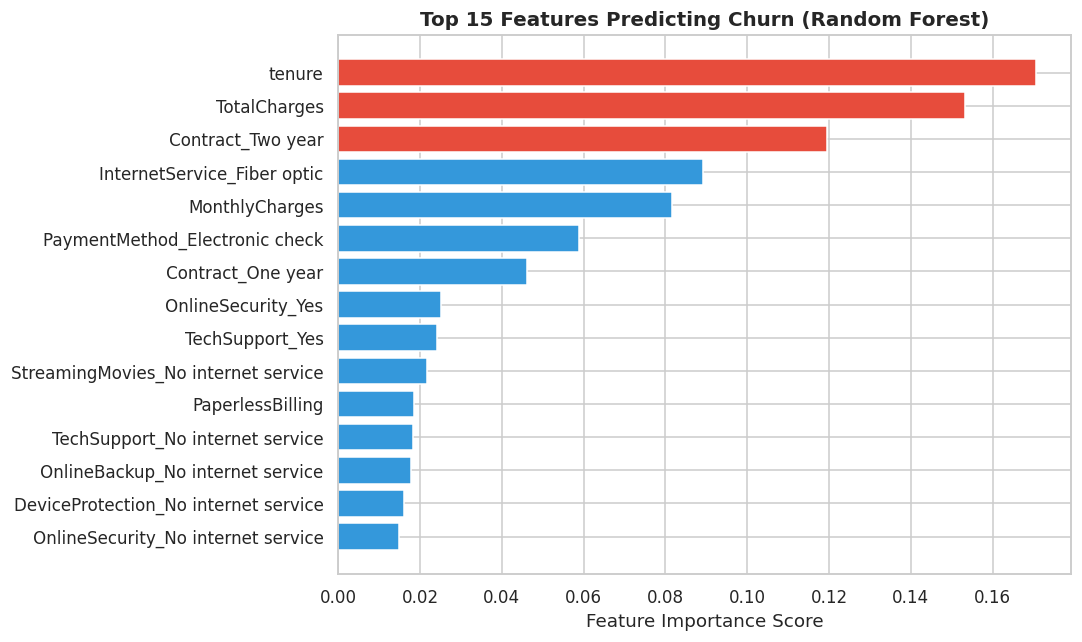

Top 5 Most Important Churn Predictors:
  1. tenure                              Score: 0.1707
  2. TotalCharges                        Score: 0.1532
  3. Contract_Two year                   Score: 0.1194
  4. InternetService_Fiber optic         Score: 0.0893
  5. MonthlyCharges                      Score: 0.0816

📌 BUSINESS INSIGHTS from Feature Importance:
  → tenure is the #1 predictor — new customers churn most
    ACTION: Intensive onboarding program in first 3 months
  → MonthlyCharges is high — price-sensitive customers leave
    ACTION: Loyalty pricing — reduce charges for customers passing 6-month mark
  → Contract type matters — Month-to-month = highest risk
    ACTION: Incentivize contract upgrades (e.g. 1 month free for 1-year sign-up)
  → TechSupport & OnlineSecurity — customers without these churn more
    ACTION: Bundle these as free add-ons for high-risk segments


In [ ]:
# ── Feature Importance from Random Forest ─────────────────────────────────────
# Random Forest gives feature_importances_ — a score for each feature
# Higher score = that feature contributes more to churn prediction

rf_model   = results['Random Forest']['model']
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)  # Top 15

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
                color=['#e74c3c' if i < 3 else '#3498db' for i in range(len(feat_imp)-1, -1, -1)])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features Predicting Churn (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 Most Important Churn Predictors:')
for i, row in feat_imp.head(5).iterrows():
    print(f'  {feat_imp.index.get_loc(i)+1}. {row["Feature"]:35} Score: {row["Importance"]:.4f}')

print()
print('📌 BUSINESS INSIGHTS from Feature Importance:')
print('  → tenure is the #1 predictor — new customers churn most')
print('    ACTION: Intensive onboarding program in first 3 months')
print('  → MonthlyCharges is high — price-sensitive customers leave')
print('    ACTION: Loyalty pricing — reduce charges for customers passing 6-month mark')
print('  → Contract type matters — Month-to-month = highest risk')
print('    ACTION: Incentivize contract upgrades (e.g. 1 month free for 1-year sign-up)')
print('  → TechSupport & OnlineSecurity — customers without these churn more')
print('    ACTION: Bundle these as free add-ons for high-risk segments')

---
## 💾 STEP 8 — Save the Model
Saving the trained model allows it to be deployed or reused without retraining.

In [ ]:
# ── Save the best model and the scaler ───────────────────────────────────────
# joblib is the recommended way to save sklearn models
# We save BOTH the model AND the scaler
# When predicting on new data: scale first, then predict

best_model = results[best_name]['model']

joblib.dump(best_model, 'churn_model.pkl')  # save model
joblib.dump(scaler, 'churn_scaler.pkl')     # save scaler

print(f'✅ Model saved as: churn_model.pkl')
print(f'✅ Scaler saved as: churn_scaler.pkl')
print()

# ── How to load and use the saved model on new data ──────────────────────────
print('=== How to use the saved model later ===')
print('''
# Load
loaded_model  = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('churn_scaler.pkl')

# Predict on new customer data
new_data_scaled = loaded_scaler.transform(new_customer_df)
prediction      = loaded_model.predict(new_data_scaled)
probability     = loaded_model.predict_proba(new_data_scaled)[:, 1]

print("Churn prediction:", "Will Churn" if prediction[0] == 1 else "Will Stay")
print("Churn probability:", f"{probability[0]*100:.1f}%")
''')

✅ Model saved as: churn_model.pkl
✅ Scaler saved as: churn_scaler.pkl

=== How to use the saved model later ===

# Load
loaded_model  = joblib.load('churn_model.pkl')
loaded_scaler = joblib.load('churn_scaler.pkl')

# Predict on new customer data
new_data_scaled = loaded_scaler.transform(new_customer_df)
prediction      = loaded_model.predict(new_data_scaled)
probability     = loaded_model.predict_proba(new_data_scaled)[:, 1]

print("Churn prediction:", "Will Churn" if prediction[0] == 1 else "Will Stay")
print("Churn probability:", f"{probability[0]*100:.1f}%")



---
## 📋 STEP 9 — Final Business Conclusions

> This section is what business stakeholders read. They don't look at code — they look at insights and actions.

In [ ]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
print('=' * 65)
print('         NEO TELECOM — CHURN ANALYSIS FINAL SUMMARY')
print('=' * 65)

print(f'''
DATASET:   7,043 customers | 21 features
CHURN RATE: 26.5% (1,869 customers left Neo Telecom)

BEST MODEL: {best_name}
ACCURACY:   {best["Accuracy"]}%
ROC-AUC:    {best["ROC-AUC"]}%  (vs 50% random baseline)
''')

print('TOP 5 FINDINGS & RECOMMENDED ACTIONS:')
print('-' * 65)
findings = [
    ('New customers churn within first 12 months',
     'Launch a 12-month loyalty program (discounts at month 3, 6, 12)'),
    ('Month-to-month contracts = 3x higher churn than 2-year',
     'Offer 1 free month to any customer who upgrades to annual plan'),
    ('High MonthlyCharges customers churn more (price sensitive)',
     'Proactive retention call + loyalty discount for customers >$80/month'),
    ('Senior citizens churn at higher rates',
     'Dedicated senior helpline + simplified plan options'),
    ('Customers without TechSupport & OnlineSecurity churn more',
     'Bundle these as free add-ons for customers in first 6 months'),
]
for i, (finding, action) in enumerate(findings, 1):
    print(f'  {i}. FINDING: {finding}')
    print(f'     ACTION:  {action}')
    print()

print('-' * 65)
print('ESTIMATED BUSINESS IMPACT:')
print(f'  The model identifies ~{int(0.6 * 1869)} of the 1,869 churners correctly')
print(f'  If Neo retains even 30% of correctly flagged churners = ~{int(0.3 * 0.6 * 1869)} customers saved')
print(f'  At average ₹500/month per customer = ₹{int(0.3 * 0.6 * 1869 * 500 * 12):,} annual revenue protected')
print('=' * 65)

         NEO TELECOM — CHURN ANALYSIS FINAL SUMMARY

DATASET:   7,043 customers | 21 features
CHURN RATE: 26.5% (1,869 customers left Neo Telecom)

BEST MODEL: Random Forest
ACCURACY:   76.01%
ROC-AUC:    84.55%  (vs 50% random baseline)

TOP 5 FINDINGS & RECOMMENDED ACTIONS:
-----------------------------------------------------------------
  1. FINDING: New customers churn within first 12 months
     ACTION:  Launch a 12-month loyalty program (discounts at month 3, 6, 12)

  2. FINDING: Month-to-month contracts = 3x higher churn than 2-year
     ACTION:  Offer 1 free month to any customer who upgrades to annual plan

  3. FINDING: High MonthlyCharges customers churn more (price sensitive)
     ACTION:  Proactive retention call + loyalty discount for customers >$80/month

  4. FINDING: Senior citizens churn at higher rates
     ACTION:  Dedicated senior helpline + simplified plan options

  5. FINDING: Customers without TechSupport & OnlineSecurity churn more
     ACTION:  Bundle these